In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

import matplotlib.pyplot as plt
from plotnine import *

num_cores = multiprocessing.cpu_count()
print(num_cores)

32


In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 1000_000

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)
# mac


In [3]:
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# Collect annotation categories
all_annotation_list = []
rare_variant_annotations_dict = config.get("rare_variant_annotations")
if rare_variant_annotations_dict:
    for category in rare_variant_annotations_dict.values():
        all_annotation_list.extend(category)

all_annotation_list

['dms_score',
 'dms_activity',
 'dms_abundance',
 'scaled_fitness',
 'fitness',
 'cadd_raw',
 'am_pathogenicity',
 'esmscoremissense',
 'gpn_score',
 'priphcons',
 'mamphcons',
 'verphcons',
 'verphylop',
 'priphylop',
 'mamphylop',
 'zoopriphylop',
 'zooverphylop',
 'af_ukb',
 'relative_cds_position',
 'relprotpos']

In [4]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6coding.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:11130589:G:A""","""mean_platelet_thrombocyte_volu…",127267,-0.001332,0.836728
"""chr1:2526571:G:C""","""mean_platelet_thrombocyte_volu…",19263,0.006027,0.827296
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [5]:
anno = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.with_columns(
    (pl.col('consequence_missense_variant') == 1)
).select(
    set(['id', 'region']).union(set(existing_annos))
).filter(
    pl.col('id').is_in(appv['id'].unique())
)

melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
    # pl.col("af_ukb").cast(pl.Float32)
)

melted_anno

/tmp/ipykernel_134898/1718422457.py:9: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score
str,str,str,f32
"""chr1:169795116:G:C""","""ENSG00000000460""","""cadd_raw""",2.172202
"""chr1:169798959:G:A""","""ENSG00000000460""","""cadd_raw""",6.18842
"""chr1:169798959:G:GT""","""ENSG00000000460""","""cadd_raw""",0.0
"""chr1:169798959:G:T""","""ENSG00000000460""","""cadd_raw""",5.926235
"""chr1:169800908:G:A""","""ENSG00000000460""","""cadd_raw""",3.04392
…,…,…,…
"""chr7:151061964:A:G""","""ENSG00000288608""","""relprotpos""",0.812
"""chr7:151061966:C:T""","""ENSG00000288608""","""relprotpos""",0.812
"""chr7:151061967:GA:G""","""ENSG00000288608""","""relprotpos""",0.0


In [6]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    pl.col('annotation').str.contains('pLoF'),
    pl.col('phenotype').is_in(appv['phenotype'].unique()),
    pl.col('region').is_in(anno['region'].unique())
)

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()
gene_trait_df

/tmp/ipykernel_134898/2241834246.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,gene_id,gene_name,phenotype,trait_type
str,str,str,str,str
"""ENSG00000214681""","""ENSG00000214681""","""IQCF5""","""reticulocyte_percentage_int""","""continuous"""
"""ENSG00000204267""","""ENSG00000204267""","""TAP2""","""cholesterol_int""","""continuous"""
"""ENSG00000022840""","""ENSG00000022840""","""RNF10""","""reticulocyte_count_int""","""continuous"""
"""ENSG00000131504""","""ENSG00000131504""","""DIAPH1""","""mean_platelet_thrombocyte_volu…","""continuous"""
"""ENSG00000073060""","""ENSG00000073060""","""SCARB1""","""red_blood_cell_erythrocyte_dis…","""continuous"""
…,…,…,…,…
"""ENSG00000183876""","""ENSG00000183876""","""ARSI""","""standing_height_int""","""continuous"""
"""ENSG00000068078""","""ENSG00000068078""","""FGFR3""","""standing_height_int""","""continuous"""
"""ENSG00000205639""","""ENSG00000205639""","""MFSD2B""","""reticulocyte_count_int""","""continuous"""


In [7]:
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

/tmp/ipykernel_134898/2529300033.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_134898/2529300033.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


(11770485, 4) (84276619, 4)


In [8]:
# Join df all the dataframes with pairs to restrict to valid (gene_id, phenotype)
# pheno_anno = appv_flt.join(anno_flt, on='id')
# pheno_anno = pheno_anno.join(gene_trait_df, on=['region', 'phenotype'])
pheno_anno = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .collect(engine='streaming')
)

print(pheno_anno.shape)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value', 'annotation_score']
]

# Apply the window expressions with .with_columns()
pheno_anno = pheno_anno.with_columns(rank_expressions)

(37362990, 10)


In [9]:
correlation_df = (
    pheno_anno
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr(pl.col("mean_pheno_value_rank"), pl.col("annotation_score")).alias("correlation")
    ).with_columns(
        pl.col("correlation").abs().alias("abs_corr"),
    )
)

# Check if the variant counts are consistent within each (region, phenotype) pair
inconsistent = (
    correlation_df
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {inconsistent.shape[0]}")

correlation_df

Inconsistent (region, phenotype) pairs: 0


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr
str,str,str,str,u32,f64,f64
"""ENSG00000110245""","""APOC3""","""hdl_cholesterol_int""","""priphylop""",295,-0.020129,0.020129
"""ENSG00000204296""","""TSBP1""","""apolipoprotein_b_int""","""priphcons""",307,-0.007362,0.007362
"""ENSG00000183765""","""CHEK2""","""platelet_crit_int""","""zooverphylop""",617,0.049628,0.049628
"""ENSG00000166603""","""MC4R""","""body_mass_index_bmi_int""","""cadd_raw""",249,0.210584,0.210584
"""ENSG00000148584""","""A1CF""","""total_bilirubin_int""","""zoopriphylop""",418,0.001174,0.001174
…,…,…,…,…,…,…
"""ENSG00000115657""","""ABCB6""","""reticulocyte_percentage_int""","""verphylop""",758,0.024877,0.024877
"""ENSG00000205250""","""E2F4""","""mean_corpuscular_haemoglobin_i…","""af_ukb""",328,-0.021194,0.021194
"""ENSG00000204421""","""LY6G6C""","""mean_corpuscular_volume_int""","""priphylop""",316,0.054091,0.054091


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 208 rows containing non-finite values.


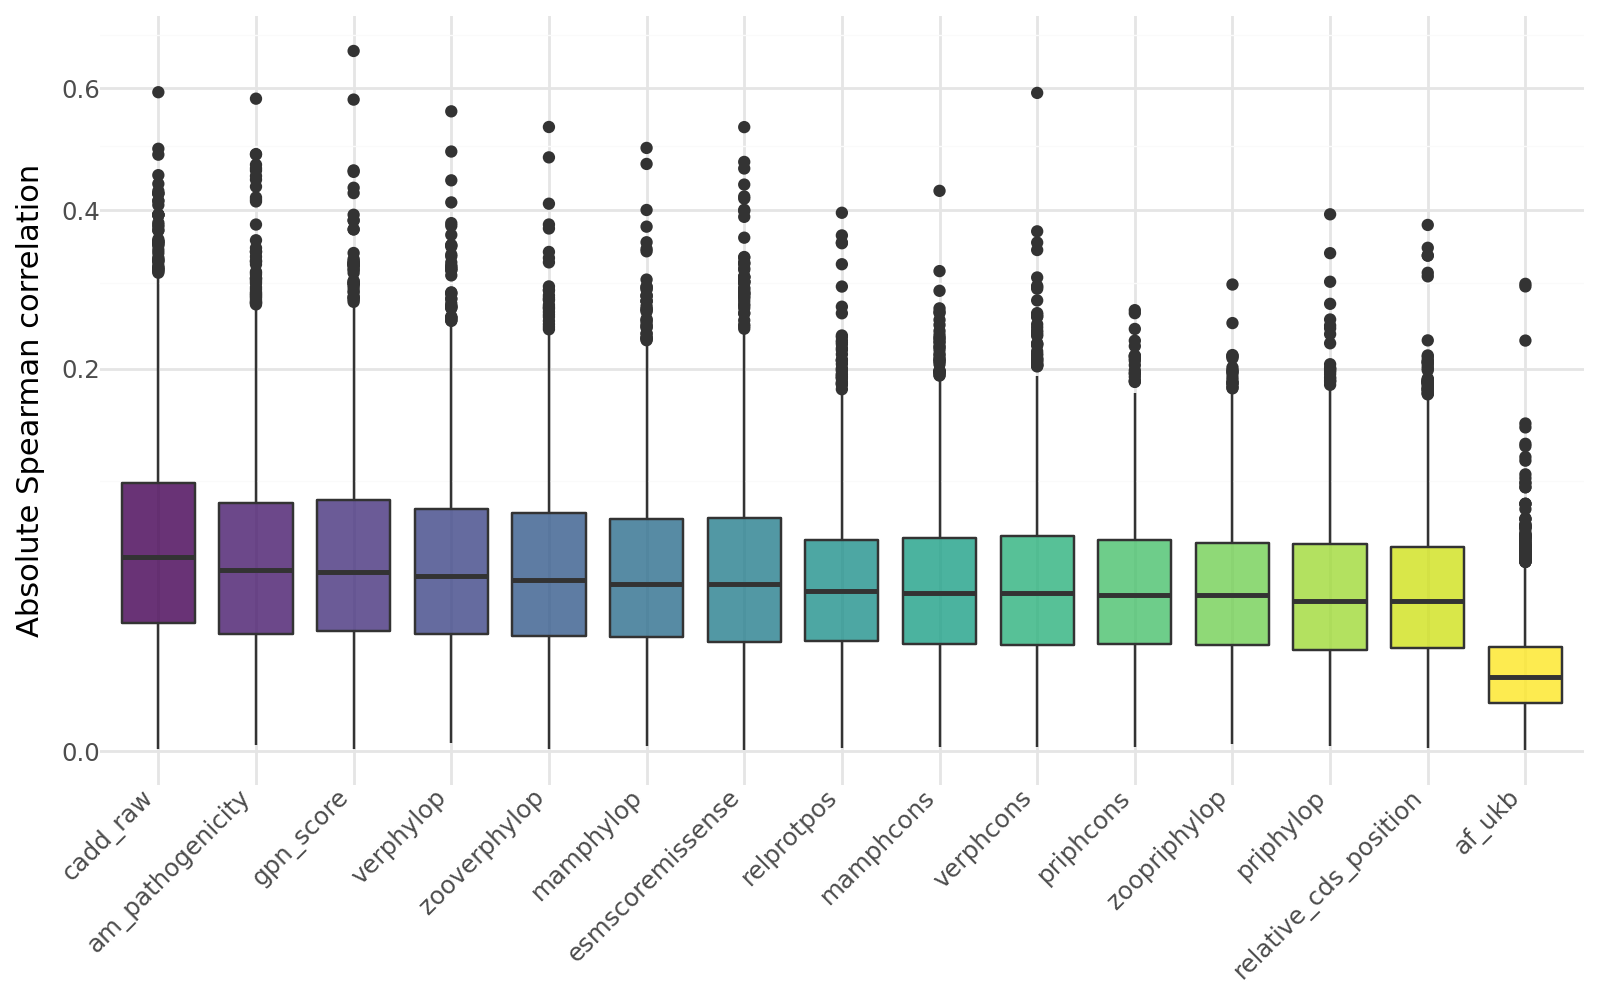

In [10]:
med_df = correlation_df.drop_nans().group_by("annotation").agg([
    pl.col("abs_corr").median().alias("median_abs_corr"),
    # pl.col("rel_abs_corr").median().alias("median_rel_abs_corr")
])

corr_pd = med_df.join(correlation_df, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# Plot
(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt() +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)